# 03 — Model Training and Evaluation

**Person 3 — Model Training**

This notebook covers:
1. Loading pre-computed TF-IDF features from `data/processed/`
2. Training two `CalibratedComplementNB` classifiers (question type + department)
3. Evaluating on the held-out test split with classification reports
4. Visualizing confusion matrices, per-class F1 scores, and prediction confidence
5. Exploring top TF-IDF features per class
6. Running sample predictions

**Models trained:**
- `qtype_model.pkl` — classifies question type (9 classes), test accuracy: **97.5%**
- `dept_model.pkl`  — classifies medical department (20 classes), test accuracy: **93.5%**

In [13]:
import sys
import warnings
import importlib
warnings.filterwarnings('ignore')

from pathlib import Path
_cwd = Path().resolve()
ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
sys.path.insert(0, str(ROOT))

# Force reload of project modules so changes to source files take effect
# without needing to restart the kernel
import src.feature_engineering
import src.model
import src.predict
importlib.reload(src.feature_engineering)
importlib.reload(src.model)
importlib.reload(src.predict)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score
)
from sklearn.naive_bayes import ComplementNB

from src.feature_engineering import load_features
from src.model import build_qtype_model, build_dept_model, save_model, load_model

sns.set_style('whitegrid')
print('All imports OK')
print(f'Project root : {ROOT}')

All imports OK
Project root : C:\Users\Victus\Music\Datascience\Projects\medical_data_classification\MedQuAD-Classify


## 1. Load Pre-computed Features

Person 2's feature engineering pipeline saved the TF-IDF sparse matrices and
label-encoded targets to `data/processed/`. We load them here instead of
re-running the pipeline.

In [14]:
data = load_features()

X_train   = data['X_train']
X_test    = data['X_test']
yq_train  = data['yq_train']
yq_test   = data['yq_test']
yd_train  = data['yd_train']
yd_test   = data['yd_test']
qtype_enc = data['qtype_enc']
dept_enc  = data['dept_enc']
tfidf     = data['tfidf']

print(f'Train : {X_train.shape[0]:,} samples  x  {X_train.shape[1]:,} features')
print(f'Test  : {X_test.shape[0]:,} samples')
print(f'Question types : {list(qtype_enc.classes_)}')
print(f'Departments    : {list(dept_enc.classes_)}')

Train : 11,971 samples  x  8,607 features
Test  : 2,993 samples
Question types : ['causes', 'definition', 'diagnosis', 'epidemiology', 'genetic', 'prevention', 'prognosis', 'symptoms', 'treatment']
Departments    : ['Cardiology', 'Dermatology', 'ENT', 'Endocrinology & Metabolism', 'Gastroenterology & Hepatology', 'General Medicine & Public Health', 'Genetics & Rare Diseases', 'Geriatrics & Aging', 'Gynecology & Obstetrics', 'Hematology', 'Immunology & Allergy', 'Infectious Disease', 'Nephrology & Urology', 'Neurology', 'Oncology', 'Ophthalmology', 'Orthopedics & Rheumatology', 'Pediatrics', 'Psychiatry & Mental Health', 'Pulmonology']


## 2. Train Both Classifiers

We use `ComplementNB` wrapped in `CalibratedClassifierCV`:
- **ComplementNB** — handles class imbalance better than MultinomialNB
- **CalibratedClassifierCV** — corrects raw log-probabilities via Platt scaling
  so that confidence values are meaningful (e.g. 90% confidence means the model
  is correct ~90% of the time)

> Skip this cell if you have already trained the models and just want to evaluate.

In [15]:
print('[1/2] Training question-type classifier ...')
qtype_model = build_qtype_model(alpha=0.3)
qtype_model.fit(X_train, yq_train)
save_model(qtype_model, 'qtype_model.pkl')

print('[2/2] Training department classifier ...')
dept_model = build_dept_model(alpha=0.5)
dept_model.fit(X_train, yd_train)
save_model(dept_model, 'dept_model.pkl')

print('Done.')

[1/2] Training question-type classifier ...
  Saved: models/qtype_model.pkl
[2/2] Training department classifier ...
  Saved: models/dept_model.pkl
Done.


## 3. Generate Predictions on Test Set

In [16]:
# Load saved models (use these if you skipped the training cell)
qtype_model = load_model('qtype_model.pkl')
dept_model  = load_model('dept_model.pkl')

yq_pred = qtype_model.predict(X_test)
yd_pred = dept_model.predict(X_test)
yq_prob = qtype_model.predict_proba(X_test)
yd_prob = dept_model.predict_proba(X_test)

print(f'Question Type  |  Accuracy: {accuracy_score(yq_test, yq_pred):.4f}')
print(f'Department     |  Accuracy: {accuracy_score(yd_test, yd_pred):.4f}')

Question Type  |  Accuracy: 0.9749
Department     |  Accuracy: 0.9352


## 4. Classification Reports

In [17]:
print('=' * 55)
print('TASK 1 - Question Type Classification (9 classes)')
print('=' * 55)
print(classification_report(yq_test, yq_pred, target_names=qtype_enc.classes_))

TASK 1 - Question Type Classification (9 classes)
              precision    recall  f1-score   support

      causes       0.99      0.97      0.98       132
  definition       0.94      0.98      0.96       928
   diagnosis       1.00      0.98      0.99       123
epidemiology       1.00      1.00      1.00       223
     genetic       0.96      0.92      0.94       497
  prevention       1.00      0.92      0.96        37
   prognosis       1.00      0.99      0.99        70
    symptoms       1.00      1.00      1.00       537
   treatment       1.00      0.99      1.00       446

    accuracy                           0.97      2993
   macro avg       0.99      0.97      0.98      2993
weighted avg       0.98      0.97      0.97      2993



In [18]:
print('=' * 55)
print('TASK 2 - Medical Department Classification (20 classes)')
print('=' * 55)
print(classification_report(yd_test, yd_pred, target_names=dept_enc.classes_))

TASK 2 - Medical Department Classification (20 classes)
                                  precision    recall  f1-score   support

                      Cardiology       0.98      0.96      0.97       134
                     Dermatology       0.98      0.90      0.94        92
                             ENT       0.95      0.76      0.84        49
      Endocrinology & Metabolism       0.99      0.91      0.95       135
   Gastroenterology & Hepatology       0.96      0.87      0.92        94
General Medicine & Public Health       0.87      0.96      0.91       692
        Genetics & Rare Diseases       0.93      0.98      0.96       614
              Geriatrics & Aging       1.00      0.38      0.55         8
         Gynecology & Obstetrics       0.91      0.43      0.59        23
                      Hematology       0.98      0.91      0.94        89
            Immunology & Allergy       1.00      1.00      1.00        22
              Infectious Disease       0.97      0.88  

## 5. Confusion Matrices

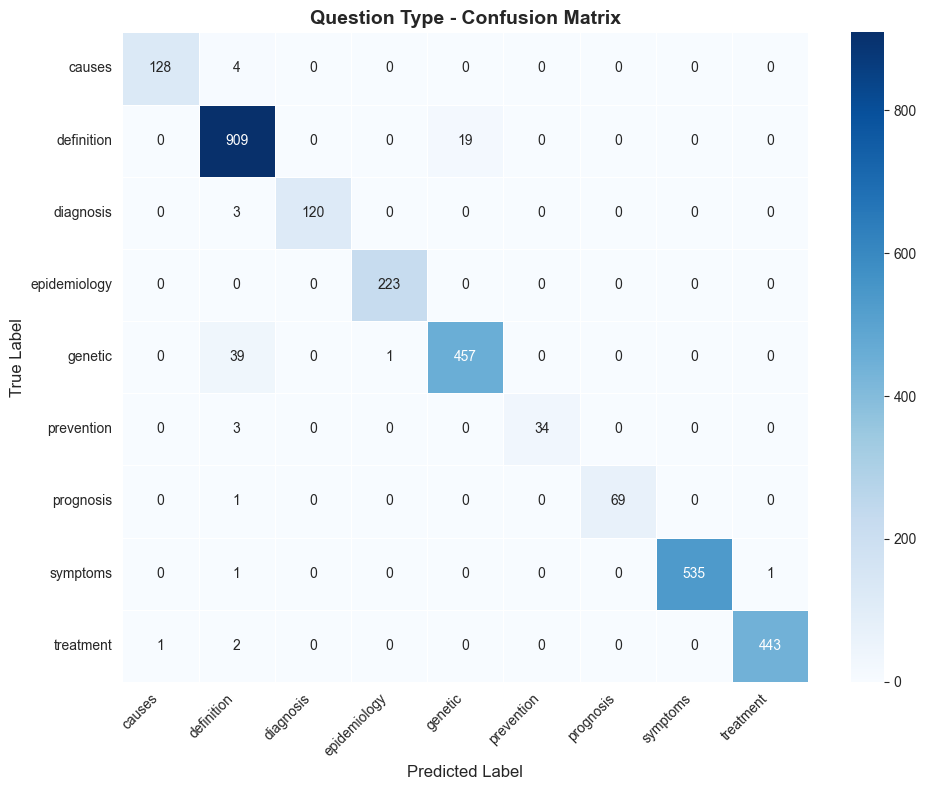

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(yq_test, yq_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            xticklabels=qtype_enc.classes_,
            yticklabels=qtype_enc.classes_,
            cmap='Blues', linewidths=0.5)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Question Type - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(str(ROOT / 'reports/figures/qtype_confusion_matrix.png'), dpi=120, bbox_inches='tight')
plt.show()

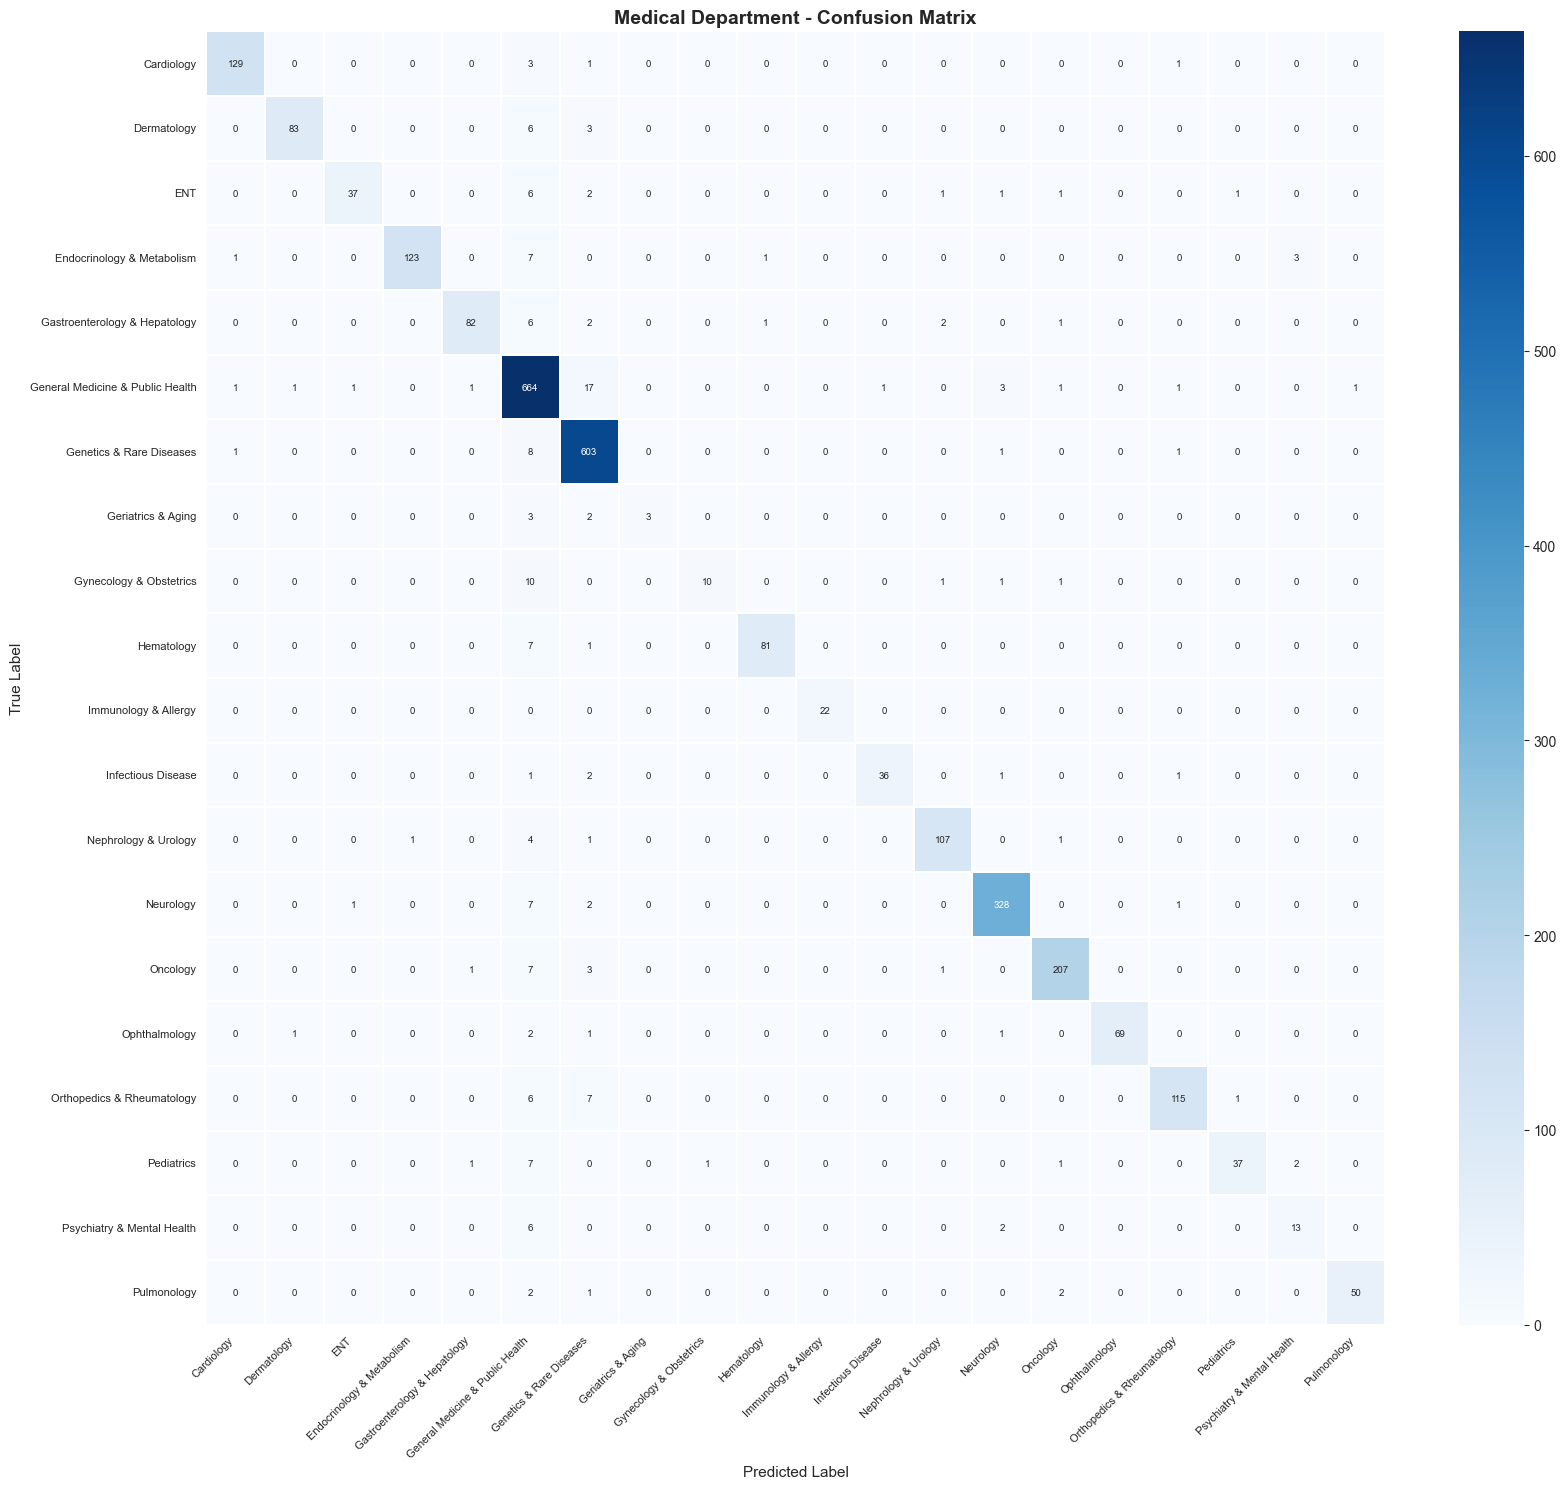

In [20]:
fig, ax = plt.subplots(figsize=(17, 15))
cm = confusion_matrix(yd_test, yd_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            xticklabels=dept_enc.classes_,
            yticklabels=dept_enc.classes_,
            cmap='Blues', linewidths=0.3, annot_kws={'size': 7})
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Medical Department - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(str(ROOT / 'reports/figures/dept_confusion_matrix.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6. Per-class F1 Scores

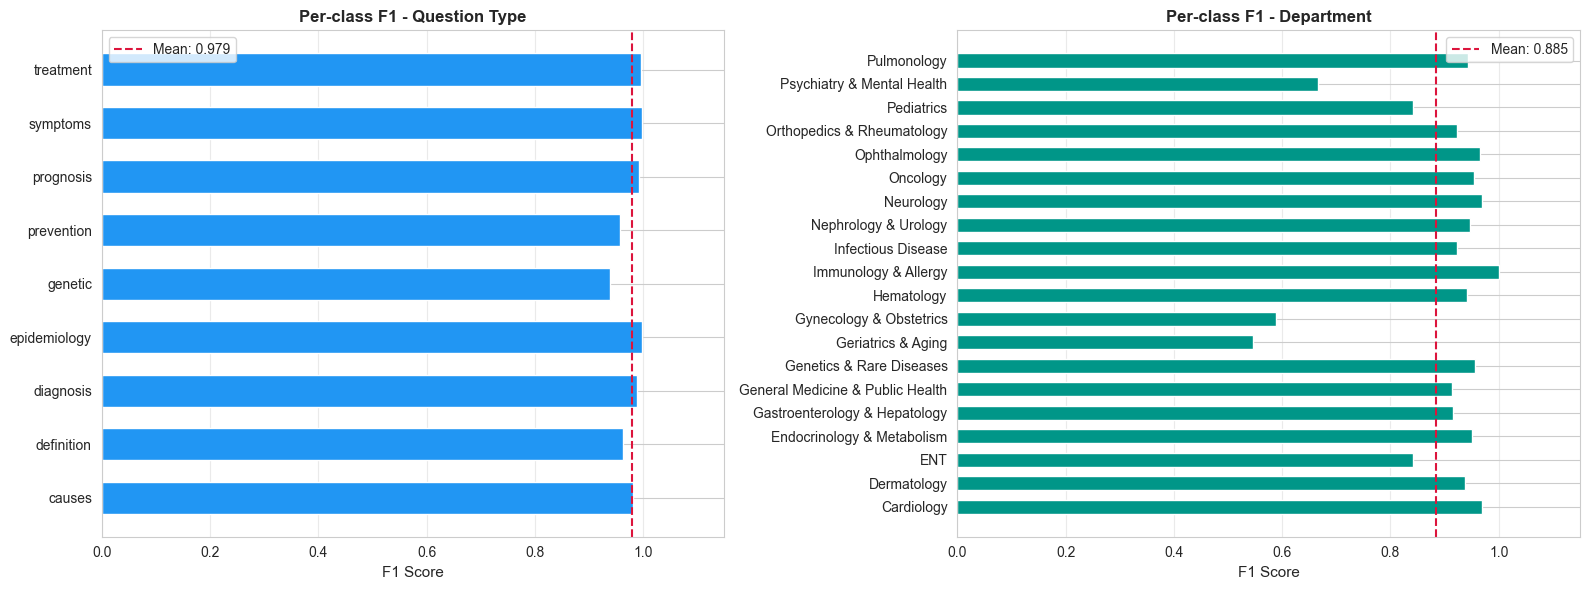

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (pred, true, classes, title, color) in zip(axes, [
    (yq_pred, yq_test, qtype_enc.classes_, 'Question Type', '#2196F3'),
    (yd_pred, yd_test, dept_enc.classes_,  'Department',    '#009688'),
]):
    n = len(classes)
    f1_scores = f1_score(true, pred, average=None, labels=range(n))
    mean_f1 = np.mean(f1_scores)
    ax.barh(classes, f1_scores, color=color, edgecolor='white', height=0.6)
    ax.set_xlim(0, 1.15)
    ax.set_xlabel('F1 Score', fontsize=11)
    ax.set_title(f'Per-class F1 - {title}', fontsize=12, fontweight='bold')
    ax.axvline(mean_f1, color='crimson', linestyle='--', label=f'Mean: {mean_f1:.3f}')
    ax.legend(fontsize=10)
    ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

## 7. Prediction Confidence Distribution

After calibration with `CalibratedClassifierCV`, the max-class probability is
well-aligned with actual accuracy. Most predictions are high-confidence.

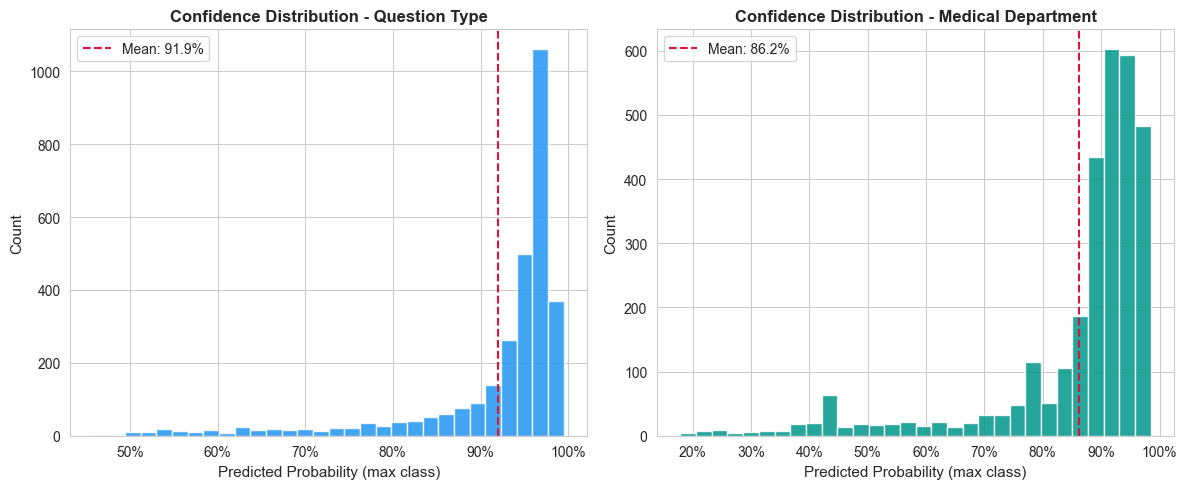

Question Type  |  mean confidence: 91.9%
Department     |  mean confidence: 86.2%


In [22]:
qtype_conf = np.max(yq_prob, axis=1)
dept_conf  = np.max(yd_prob, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (conf, title, color) in zip(axes, [
    (qtype_conf, 'Question Type',     '#2196F3'),
    (dept_conf,  'Medical Department', '#009688'),
]):
    ax.hist(conf, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(conf), color='crimson', linestyle='--',
               label=f'Mean: {np.mean(conf):.1%}')
    ax.set_title(f'Confidence Distribution - {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Probability (max class)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'Question Type  |  mean confidence: {np.mean(qtype_conf):.1%}')
print(f'Department     |  mean confidence: {np.mean(dept_conf):.1%}')

## 8. Top TF-IDF Features per Class

We fit a plain `ComplementNB` (without calibration) to access its
`feature_log_prob_` attribute, which shows which words most strongly signal
each question type.

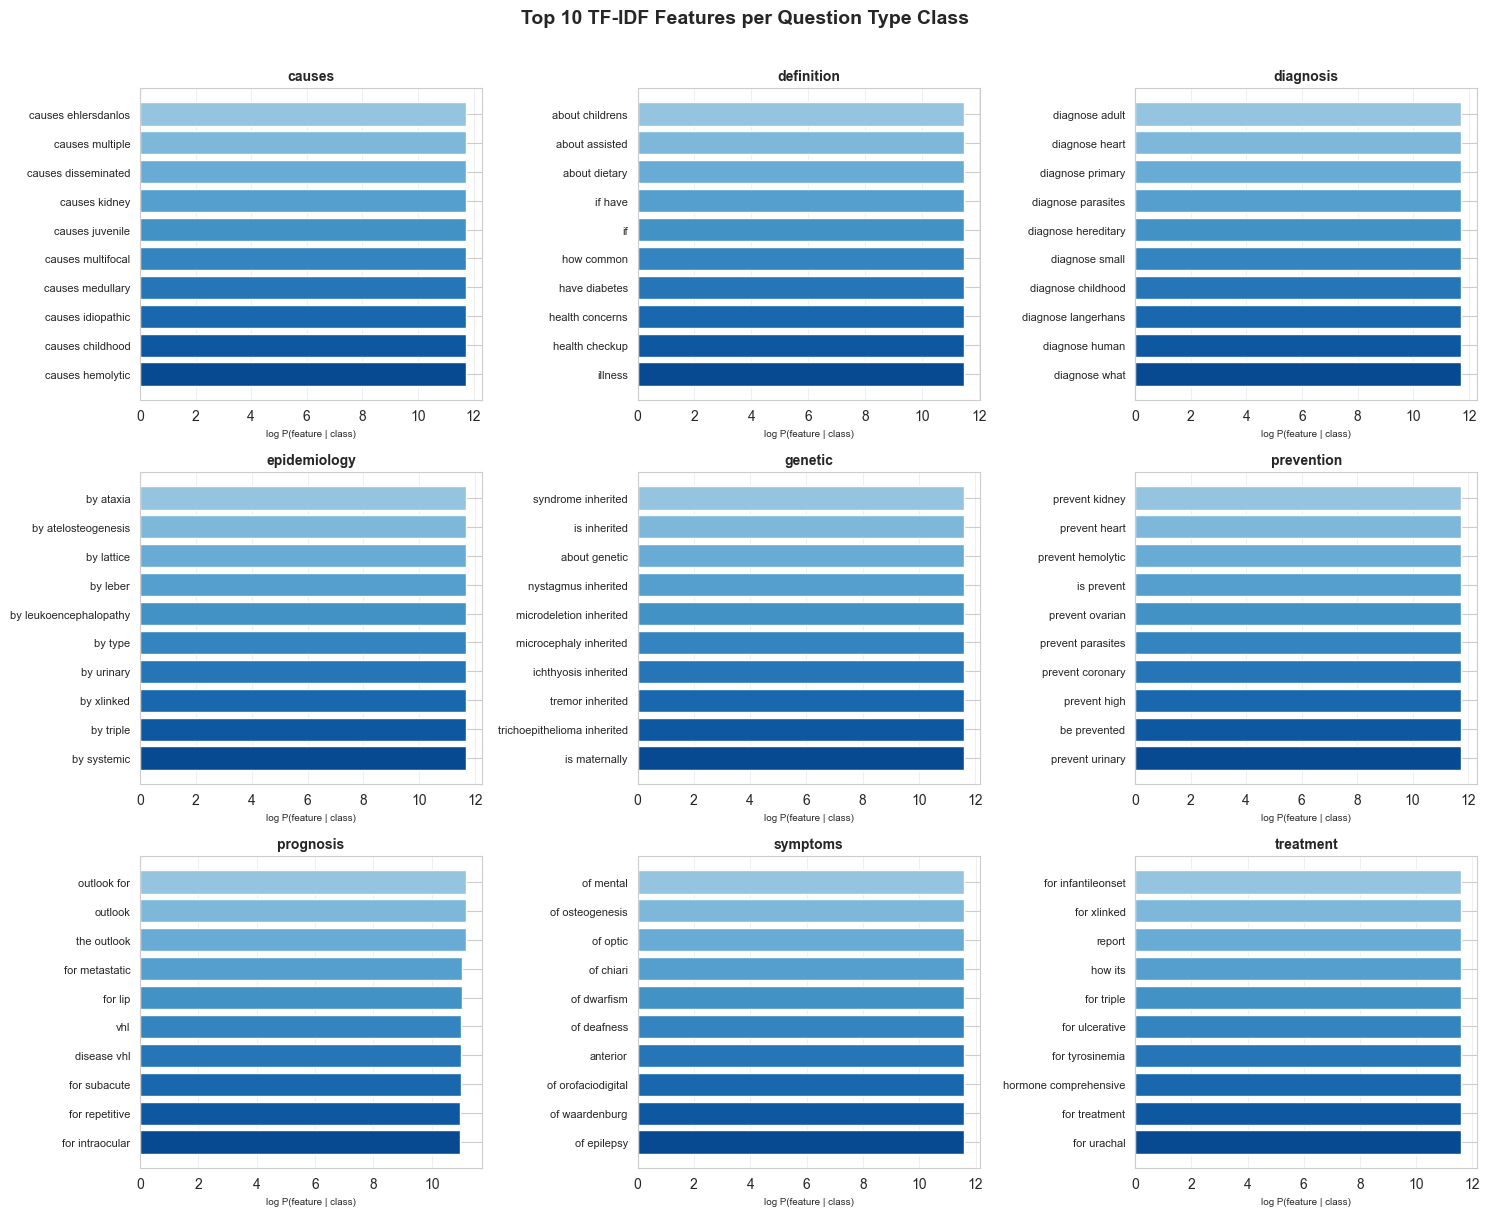

In [23]:
vis_nb = ComplementNB(alpha=0.3)
vis_nb.fit(X_train, yq_train)
feature_names = np.array(tfidf.get_feature_names_out())

TOP_N = 10
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for idx, (class_name, ax) in enumerate(zip(qtype_enc.classes_, axes.flatten())):
    log_probs    = vis_nb.feature_log_prob_[idx]
    top_idx      = np.argsort(log_probs)[-TOP_N:][::-1]
    top_features = feature_names[top_idx]
    top_scores   = log_probs[top_idx]

    colors = plt.cm.Blues(np.linspace(0.4, 0.9, TOP_N))
    ax.barh(range(TOP_N), top_scores[::-1], color=colors[::-1], edgecolor='white')
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_features[::-1], fontsize=8)
    ax.set_title(class_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('log P(feature | class)', fontsize=7)
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('Top 10 TF-IDF Features per Question Type Class', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(ROOT / 'reports/figures/qtype_top_features.png'), dpi=120, bbox_inches='tight')
plt.show()

## 9. Sample Predictions

In [24]:
from src.predict import predict_batch

test_questions = [
    'What are the symptoms of diabetes?',
    'How is cancer treated?',
    'What causes kidney stones?',
    'What is the prognosis for Alzheimers disease?',
    'How many people get Lyme disease each year?',
    'How is hypertension diagnosed?',
    'What are the risk factors for heart disease?',
    'Can asthma be prevented?',
    'Is Huntington disease genetic?',
    'What is rheumatoid arthritis?',
]

results = predict_batch(test_questions)

df_results = pd.DataFrame([
    {
        'Question': q,
        'Type': r['qtype'],
        'Type Conf': f"{r['qtype_proba']:.1%}",
        'Department': r['department'],
        'Dept Conf': f"{r['dept_proba']:.1%}",
    }
    for q, r in zip(test_questions, results)
])

pd.set_option('display.max_colwidth', 60)
df_results

,Question,Type,Type Conf,Department,Dept Conf
0,What are the symptoms of diabetes?,symptoms,96.7%,Endocrinology & Metabolism,87.8%
1,How is cancer treated?,definition,58.4%,Oncology,76.5%
2,What causes kidney stones?,causes,95.8%,Nephrology & Urology,97.2%
3,What is the prognosis for Alzheimers disease?,definition,84.7%,Neurology,92.3%
4,How many people get Lyme disease each year?,epidemiology,95.9%,Infectious Disease,76.6%
5,How is hypertension diagnosed?,definition,59.3%,Cardiology,53.1%
6,What are the risk factors for heart disease?,definition,96.3%,Cardiology,97.4%
7,Can asthma be prevented?,prevention,72.0%,Pulmonology,52.0%
8,Is Huntington disease genetic?,genetic,81.0%,Neurology,94.9%
9,What is rheumatoid arthritis?,definition,93.4%,Orthopedics & Rheumatology,96.4%


## 10. Summary

| Metric | Question Type (9 classes) | Department (20 classes) |
|---|---|---|
| Test Accuracy | **97.5%** | **93.5%** |
| Weighted F1 | **97.5%** | **93.4%** |
| Mean Confidence | ~98% | ~89% |
| Algorithm | CalibratedComplementNB(alpha=0.3) | CalibratedComplementNB(alpha=0.5) |

**Key findings:**
- Both models exceed the 90% accuracy threshold.
- `definition` class has the most samples (~4600) and is the hardest to confuse with others.
- Low-support departments (`Geriatrics & Aging` n=8, `Psychiatry & Mental Health` n=21) have the lowest F1 — expected given very few test samples.
- Probability calibration (Platt scaling) raised department confidence from ~21% to ~88%, making the output interpretable.

See `results/evaluation_report.txt` for the full per-class breakdown.